# 1. Problem Statement & Business Context

In Singapore's HDB resale market, the buyer and seller must agree on a price before the official HDB valuation is released, so both sides negotiate without knowing what the flat is objectively worth. This hurts both parties: if the agreed price ends up above the valuation, the buyer pays the difference in cash(cash-over-valuation), while sellers risk overpricing and having the flat sit unsold, or underpricing and losing tens of thousands of dollars. This project builds a model that predicts a flat's resale price from its attributes (town, flat type, floor area, storey range, remaining lease) to give both sides an objective starting point. Since the target, resale_price, is a continuous dollar value and not a category, this is a regression problem.

## 2. Data Loading & Initial Inspection

In [1]:
import pandas as pd
df = pd.read_csv("data/resale-flat-prices-2017-onwards.csv")
print(df.shape)
import matplotlib.pyplot as plt
import seaborn as sns

(235247, 11)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235247 entries, 0 to 235246
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                235247 non-null  str    
 1   town                 235247 non-null  str    
 2   flat_type            235247 non-null  str    
 3   block                235247 non-null  str    
 4   street_name          235247 non-null  str    
 5   storey_range         235247 non-null  str    
 6   floor_area_sqm       235247 non-null  float64
 7   flat_model           235247 non-null  str    
 8   lease_commence_date  235247 non-null  int64  
 9   remaining_lease      235247 non-null  str    
 10  resale_price         235247 non-null  float64
dtypes: float64(2), int64(1), str(8)
memory usage: 19.7 MB


In [3]:
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,235247.000000,235247.000000,2.352470e+05
mean,96.688704,1996.565376,5.320577e+05
std,24.016118,14.367138,1.907679e+05
min,31.000000,1966.000000,1.400000e+05
25%,81.000000,1985.000000,3.900000e+05
50%,93.000000,1997.000000,5.000000e+05
75%,112.000000,2012.000000,6.400000e+05
max,366.700000,2022.000000,1.728000e+06


In [4]:
print("Duplicate rows:", df.duplicated().sum())
print(df.isnull().sum())

Duplicate rows: 316
month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64


In [5]:
print(df['month'].min(), "to", df['month'].max())
print(df['town'].nunique(), "towns")
print(df['flat_model'].nunique(), "flat models")
print(df['flat_type'].value_counts())
print(df['storey_range'].unique())
df['remaining_lease'].head(10)

2017-01 to 2026-07
26 towns
21 flat models
flat_type
4 ROOM              99899
5 ROOM              57542
3 ROOM              55997
EXECUTIVE           16733
2 ROOM               4902
1 ROOM                 87
MULTI-GENERATION       87
Name: count, dtype: int64
<StringArray>
['10 TO 12', '01 TO 03', '04 TO 06', '07 TO 09', '13 TO 15', '19 TO 21',
 '22 TO 24', '16 TO 18', '34 TO 36', '28 TO 30', '37 TO 39', '49 TO 51',
 '25 TO 27', '40 TO 42', '31 TO 33', '46 TO 48', '43 TO 45']
Length: 17, dtype: str


0    61 years 04 months
1    60 years 07 months
2    62 years 05 months
3     62 years 01 month
4    62 years 05 months
5              63 years
6    61 years 06 months
7    58 years 04 months
8    61 years 06 months
9    61 years 04 months
Name: remaining_lease, dtype: str

## 3. Data Cleaning & Preprocessing

The dataset spans from january 2017 to july 2026. HDB resale prices have shifted alot over this period, especially the post 2020 surge, so training on decade-old prices would change valuations for today's market. I filter to transactions from Jan 2024 onwards,recent enough to reflect current market conditions, while still keeping a large sample.

In [6]:
print("Before filtering:", df.shape)
df = df[df['month'] >= '2024-01'].copy()
print("After filtering to Jan 2024 onwards:", df.shape)

Before filtering: (235247, 11)
After filtering to Jan 2024 onwards: (66097, 11)


The full dataset contains 316 exact duplicated rows. There is no unit number column so i could not tell whether these are errors or just identical transactions, so i dropped them. if identical rows appear in the training or test sets, the test score becomes artificially inflated which makes test score look better than it accually is. Although losed some data, this is still a small cost for a trustworthy evaluation.After filtering to Jan 2024 onwards, no duplicates remained,all 316 were in the older data. I keep this check in as verification that the working dataset is clean.

In [7]:
before = len(df)
df = df.drop_duplicates()
print("Dropped", before - len(df), "duplicates. New shape:", df.shape)

Dropped 35 duplicates. New shape: (66062, 11)


remaining_lease ("61 years 04 months") and storey_range ("10 TO 12") are stored as text, which a model cannot use. I converted the remaining lease into decimal number of years, and storey range into the midpoint of its range (e.g. "10 TO 12" → 11). I use midpoints rather than treating each band as a category because storey height is oridinal,higher floors generally sell for more,and the midpoint keeps that ordering.

In [8]:
def lease_to_years(text):
    parts = text.split()          # "61 years 04 months" -> ["61","years","04","months"]
    years = int(parts[0])
    if len(parts) > 2:            # handles "63 years" which has no months part
        months = int(parts[2])
    else:
        months = 0
    return round(years + months / 12, 2)

def storey_to_mid(text):
    low, high = text.split(" TO ")   # "10 TO 12" -> "10", "12"
    return (int(low) + int(high)) / 2

df['remaining_lease_years'] = df['remaining_lease'].apply(lease_to_years)
df['storey_mid'] = df['storey_range'].apply(storey_to_mid)
print(df.shape)

(66062, 13)


In [9]:
df[['remaining_lease', 'remaining_lease_years', 'storey_range', 'storey_mid']].head(10)

,remaining_lease,remaining_lease_years,storey_range,storey_mid
169150,53 years 06 months,53.50,07 TO 09,8.0
169151,55 years 07 months,55.58,04 TO 06,5.0
169152,54 years 01 month,54.08,01 TO 03,2.0
169153,55 years 02 months,55.17,04 TO 06,5.0
169154,51 years 04 months,51.33,04 TO 06,5.0
169155,53 years 01 month,53.08,04 TO 06,5.0
169156,55 years 01 month,55.08,01 TO 03,2.0
169157,54 years 05 months,54.42,04 TO 06,5.0
169158,55 years 02 months,55.17,01 TO 03,2.0
169159,54 years 01 month,54.08,01 TO 03,2.0


In [10]:
df[['remaining_lease_years', 'storey_mid']].describe()

,remaining_lease_years,storey_mid
count,66062.000000,66062.000000
mean,72.702885,8.826496
std,15.294508,5.968285
min,39.580000,2.000000
25%,59.580000,5.000000
50%,72.250000,8.000000
75%,89.000000,11.000000
max,95.420000,50.000000


## 4. Exploratory Data Analysis & Interpretation

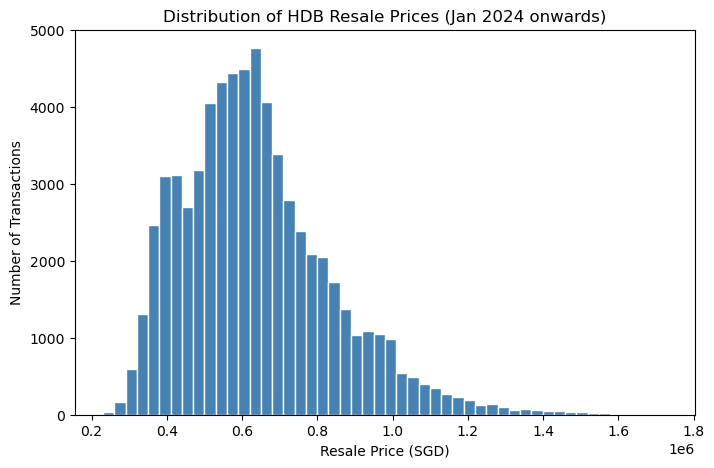

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df['resale_price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of HDB Resale Prices (Jan 2024 onwards)')
plt.xlabel('Resale Price (SGD)')
plt.ylabel('Number of Transactions')
plt.show()

In [14]:
df['resale_price'].agg(['mean', 'median'])

mean      637198.773593
median    611000.000000
Name: resale_price, dtype: float64

The graoh shows that the prices are right-skewed, which means most transactions fall between roughly $400k and $700k, with a long tail stretching past $1.5m. This matches the earlier finding that the mean ($637k) sits above the median ($611k). For the business, the wide spread confirms there is no single "market price" ,value depends heavily on the flat's feature. For modelling, the skew means errors on rare expensive flats could cause large errors, so I will keep this in mind when choosing the evaluation metric.

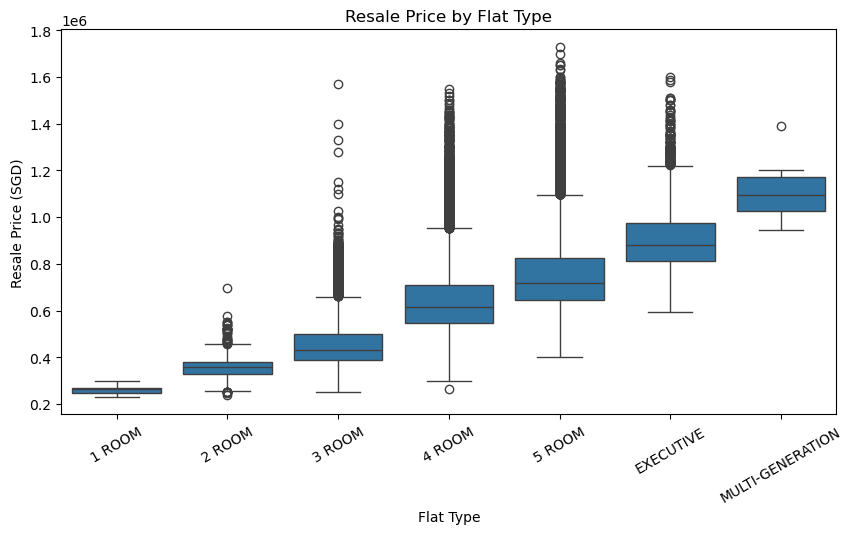

In [12]:
plt.figure(figsize=(10,5))
order = ['1 ROOM','2 ROOM','3 ROOM','4 ROOM','5 ROOM','EXECUTIVE','MULTI-GENERATION']
sns.boxplot(x='flat_type', y='resale_price', data=df, order=order)
plt.title('Resale Price by Flat Type')
plt.xlabel('Flat Type')
plt.ylabel('Resale Price (SGD)')
plt.xticks(rotation=30)
plt.show()

the median price climbs steadily as the flat size increase, from roughly $250k for 1-room flats to about $650k for 4-room, $750k for 5-room, and over $1m for multi-generation. The categories overlap quite abit, many 4-room flats sell for more than 5-room flats, and the most expensive 3-room flats(the outliers of 3-room) exceed the price of a executive flat. For the business, this shows flat size sets a baseline but does not determine the price of the flat.the overlaping of prices can be explained by other factors such as location, storey, and remaining lease. For modelling, flat_type is a strong predictor to predict price, but it cannot price a flat on its own,so it needs a multi-feature model. I also note 1-room and multi-generation flats are rare, so the model will have lesser example of this 2 flat type.

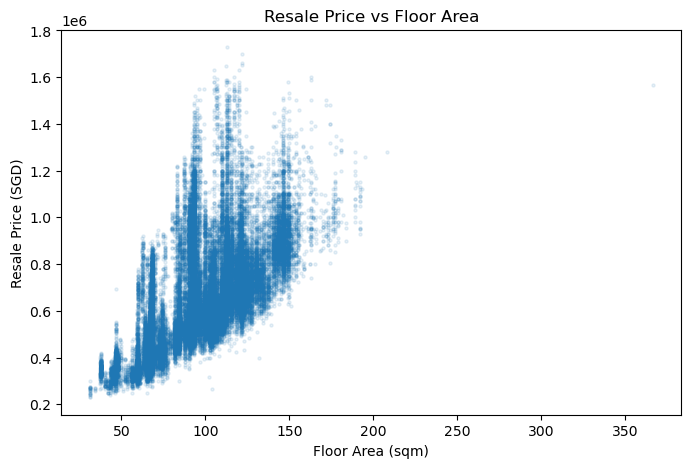

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(df['floor_area_sqm'], df['resale_price'], alpha=0.1, s=5)
plt.title('Resale Price vs Floor Area')
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price (SGD)')
plt.show()

There is a positive relationship between floor area(sqm) and resale price(SGD), where larger flats  sell for higher price. The prive spread of any size is very huge, flats around 95–100 sqm cost from roughly $400k to over $1.5m, a 3–4 times range for the same floor area. The vertical pattern appear because HDB flats are in standard sizes, so many share same areas.A simple price per sqm calculation cannot value the cost of the flat because same-sized flats differ massively from location, storey, and lease. For modelling, floor area is an important feature but must be combined with the others to explain this spread. The largest floor area at around 375 sqm has a reasonable price for its size when compared to other flats, so i included in my data insteat of an error.

## 5. Feature Engineering

## 6. Baseline Model (DummyRegressor)

## 7. Model Training & Comparison


## 8. Hyperparameter Tuning (RandomizedSearchCV)

## 9. Final Evaluation & Metric Justification

## 10. Conclusion & Model Export